In [ ]:
import numpy as np
import mpmath
import matplotlib.pyplot as plt
import pygridsynth as gridsynth

from bloqade import squin
from bloqade.cirq_utils import emit_circuit
import cirq

def circuit_with_t_injection(gate_string):
    # Inizializziamo i contatori per il report tecnico richiesto
    stats = {"cnot_count": 0, "ancilla_used": 1} 

    @squin.kernel
    def circ():
        # Allocazione di 2 qubit: [0] è il Data Qubit, [1] è l'Ancilla
        q = squin.qalloc(2)
        data = q[0]
        ancilla = q[1]

        for char in gate_string:
            if char == "H":
                squin.h(data)
            elif char == "S":
                squin.s(data)
            elif char == "X":
                squin.x(data)
            elif char == "Y":
                squin.y(data)
            elif char == "Z":
                squin.z(data)
            elif char == "T":
                # --- INIZIO PROTOCOLLO DI INIEZIONE ---
                # 1. Prepariamo lo stato magico sull'ancilla
                squin.h(ancilla)
                squin.t(ancilla) # Il gate T è permesso solo qui
                
                # 2. Trasferimento tramite CNOT (controllo=ancilla, target=data)
                squin.control(ancilla).x(data)
                
                # 3. Pulizia dell'ancilla (necessaria per il prossimo gate T)
                # In una simulazione reale con post-selezione, 
                # resetteremmo l'ancilla qui.
                squin.h(ancilla) 
                # --------------------------------------
                stats["cnot_count"] += 1
            
        return q

    # Generazione del circuito
    c = emit_circuit(circ, ignore_returns=True)
    return c, stats

def rz(theta):
    return np.array([[np.exp(-1j * theta / 2), 0],
                     [0, np.exp(1j * theta / 2)]], dtype=complex)

def distance(U, V):
    tr = np.trace(U.conj().T @ V)
    val = 1 - np.abs(tr)/2
    if val < 0: val = 0
    return np.sqrt(val)

In [2]:
mpmath.mp.dps = 128
epsilon = mpmath.mpf("1e-4")

exact_gates = {0: "Z", 1: "S", 2: "T"}

results = []
for n in range(6):
    theta_val = np.pi / (2**n)
    theta_mp = mpmath.mpf(mpmath.pi) / (2**n)
    
    if n in exact_gates:
        gates = exact_gates[n]
    else:
        # Synthesize with pygridsynth
        gates = gridsynth.gridsynth_gates(theta=theta_mp, epsilon=epsilon)
    
    # Evaluate distance
    U_approx = string_to_unitary(gates)
    U_target = rz(theta_val)
    dist = distance(U_target, U_approx)
    
    t_count = gates.count("T")
    results.append({
        "n": n,
        "gates": gates,
        "length": len(gates),
        "t_count": t_count,
        "distance": dist
    })
    print(f"n={n}: target Rz(pi/{2**n})")
    print(f"  Distance: {dist:.2e}")
    print(f"  T-count:  {t_count}")
    print(f"  Length:   {len(gates)}")
    print(f"  Sequence: {gates}\n")


n=0: target Rz(pi/1)
  Distance: 0.00e+00
  T-count:  0
  Length:   1
  Sequence: Z

n=1: target Rz(pi/2)
  Distance: 0.00e+00
  T-count:  0
  Length:   1
  Sequence: S

n=2: target Rz(pi/4)
  Distance: 0.00e+00
  T-count:  1
  Length:   1
  Sequence: T

n=3: target Rz(pi/8)
  Distance: 3.08e-05
  T-count:  44
  Length:   110
  Sequence: HTHTHTSHTSHTHTHTHTHTSHTSHTHTHTHTHTSHTHTHTHTSHTSHTHTHTSHTHTSHTSHTSHTSHTHTHTSHTHTSHTSHTSHTSHTHTHTHTSHTSHTHTSHTSW

n=4: target Rz(pi/16)
  Distance: 3.03e-05
  T-count:  42
  Length:   111
  Sequence: SHTSHTHTSHTHTHTHTHTSHTHTHTSHTSHTHTHTSHTSHTSHTHTSHTSHTHTHTHTSHTSHTSHTSHTHTSHTSHTSHTSHTHTSHTSHTHTSHTHTSHTSHTHTSWW

n=5: target Rz(pi/32)
  Distance: 1.80e-05
  T-count:  36
  Length:   97
  Sequence: HTSHTHTHTHTSHTSHTSHTSHTSHTSHTHTHTHTHTHTHTHTSHTHTHTHTSHTSHTHTSHTSHTHTHTSHTHTSHTSHTHTSHTHTHSWWWWWWW



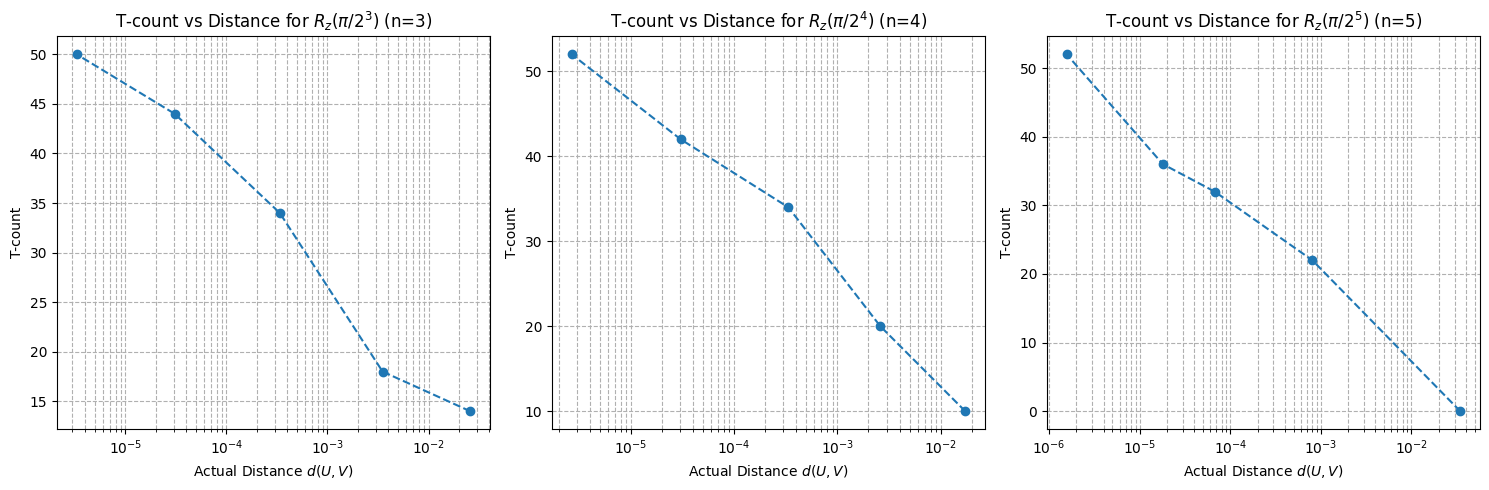

In [3]:
# Visualizing T-count vs Distance (epsilon scaling) for non-Clifford rotations
epsilons = [mpmath.mpf(f"1e-{i}") for i in range(1, 6)]

# We skip n=0, 1, 2 as they can be exactly implemented with 0 or 1 T-gates
n_values = [3, 4, 5]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes = axes.flatten()

for i, n_val in enumerate(n_values):
    distances = []
    t_counts = []

    theta_mp = mpmath.mpf(mpmath.pi) / (2**n_val)
    theta_val = np.pi / (2**n_val)
    U_target = rz(theta_val)

    for eps in epsilons:
        gates = gridsynth.gridsynth_gates(theta=theta_mp, epsilon=eps)
        U_approx = string_to_unitary(gates)
        dist = distance(U_target, U_approx)
        
        distances.append(dist)
        t_counts.append(gates.count("T"))

    ax = axes[i]
    ax.plot(distances, t_counts, marker="o", linestyle="--")
    
    if all(d > 0 for d in distances):
        ax.set_xscale("log")
    
    ax.set_xlabel("Actual Distance $d(U, V)$")
    ax.set_ylabel("T-count")
    ax.set_title(f"T-count vs Distance for $R_z(\\pi/2^{{{n_val}}})$ (n={n_val})")
    ax.grid(True, which="both", ls="--")

plt.tight_layout()
plt.show()

**PART 3**: Non-Clifford gates are expensive

In [4]:
from bloqade import squin
from bloqade.cirq_utils import emit_circuit
import cirq

def circuit_with_t_injection(gate_string):
    # Inizializziamo i contatori per il report tecnico richiesto
    stats = {"cnot_count": 0, "ancilla_used": 1} 

    @squin.kernel
    def circ():
        # Allocazione di 2 qubit: [0] è il Data Qubit, [1] è l'Ancilla
        q = squin.qalloc(2)
        data = q[0]
        ancilla = q[1]

        for char in gate_string:
            if char == "H":
                squin.h(data)
            elif char == "S":
                squin.s(data)
            elif char == "X":
                squin.x(data)
            elif char == "Y":
                squin.y(data)
            elif char == "Z":
                squin.z(data)
            elif char == "T":
                # --- INIZIO PROTOCOLLO DI INIEZIONE ---
                # 1. Prepariamo lo stato magico sull'ancilla
                squin.h(ancilla)
                squin.t(ancilla) # Il gate T è permesso solo qui
                
                # 2. Trasferimento tramite CNOT (controllo=ancilla, target=data)
                squin.control(ancilla).x(data)
                
                # 3. Pulizia dell'ancilla (necessaria per il prossimo gate T)
                # In una simulazione reale con post-selezione, 
                # resetteremmo l'ancilla qui.
                squin.h(ancilla) 
                # --------------------------------------
                stats["cnot_count"] += 1
            
        return q

    # Generazione del circuito
    c = emit_circuit(circ, ignore_returns=True)
    return c, stats

In [6]:
def get_injection_metrics(n_val, eps_list):
    stats_list = []
    theta_mp = mpmath.mpf(mpmath.pi) / (2**n_val)
    theta_val = np.pi / (2**n_val)
    U_target = rz(theta_val)

    for eps in eps_list:
        # 1. Sintesi Clifford+T (come in Parte 2)
        gates = gridsynth.gridsynth_gates(theta=theta_mp, epsilon=eps)
        
        # 2. Generazione del circuito con iniezione (Parte 3)
        circuit, stats = circuit_with_t_injection(gates)
        
        # 3. Calcolo Distanza (Post-selezione: guardiamo il qubit dati)
        # Otteniamo la matrice 4x4 e prendiamo il blocco in alto a sinistra (ancilla=0)
        full_unitary = cirq.unitary(circuit)
        U_approx = full_unitary[0:2, 0:2] * np.sqrt(2) # Normalizzazione post-selezione
        
        dist = distance(U_target, U_approx)
        
        stats_list.append({
            "epsilon": float(eps),
            "t_count": gates.count("T"),
            "cnot_count": stats["cnot_count"],
            "depth": len(cirq.Circuit(circuit.all_operations())),
            "distance": dist
        })
    return stats_list

# Eseguiamo il test per Rz(pi/32) -> n=5
epsilons = [mpmath.mpf(f"1e-{i}") for i in range(2, 7)]
data_p3 = get_injection_metrics(5, epsilons)

# Stampiamo un'anteprima dei costi
print(f"Scaling dei costi per Rz(pi/32) con Iniezione:")
for d in data_p3:
    print(f"Eps: {d['epsilon']:.1e} | T-gates: {d['t_count']} | CNOTs: {d['cnot_count']} | Depth: {d['depth']}")

TypeError: unhashable type: 'dict'